In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score



In [ ]:
dataset = pd.read_csv('/content/SNP.csv')
dataset.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [ ]:
dataset.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [ ]:
dataset.isnull().sum()

,0
Age,0
EstimatedSalary,0
Purchased,0


In [ ]:
dataset['Purchased'].value_counts()

,count
Purchased,
0,257
1,143


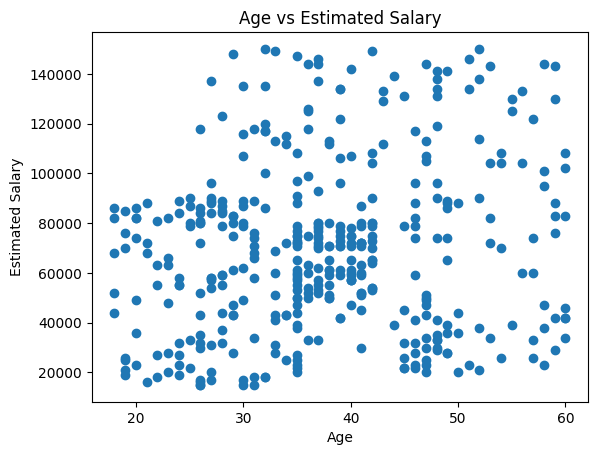

In [ ]:
plt.scatter(dataset['Age'], dataset['EstimatedSalary'])
plt.title('Age vs Estimated Salary')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.show()

In [ ]:
X = dataset[['Age','EstimatedSalary']].values
y = dataset['Purchased'].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
#Apply Model
model = SVC(kernel = 'linear', random_state=0)
model.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
# Test data for prediction
pred1 = model.predict(sc.transform([[30, 87000]]))
pred1

array([0])

In [ ]:
accuracy_score(y_test, y_pred)

0.9125

In [ ]:
cm  = confusion_matrix(y_test, y_pred)
cm

array([[57,  1],
       [ 6, 16]])

In [ ]:
def plot_decision_boundary(X_set, y_set, title):
    X1, X2 = np.meshgrid(
        np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
        np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
    )

    plt.figure()
    plt.contourf(
        X1, X2,
        model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
        alpha=0.3
    )

    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(
            X_set[y_set == j, 0],
            X_set[y_set == j, 1],
            label=j
        )

    plt.title(title)
    plt.xlabel('Age')
    plt.ylabel('Estimated Salary')
    plt.legend()

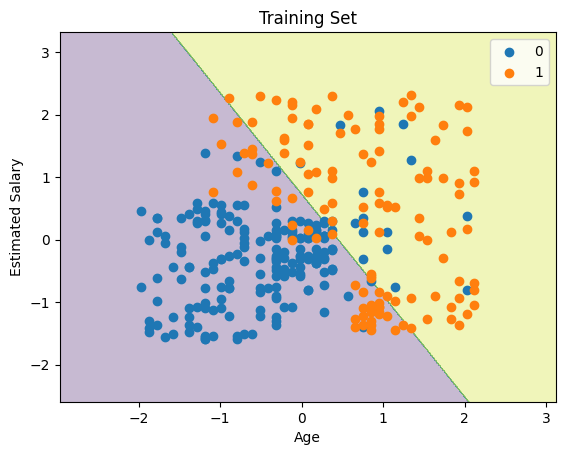

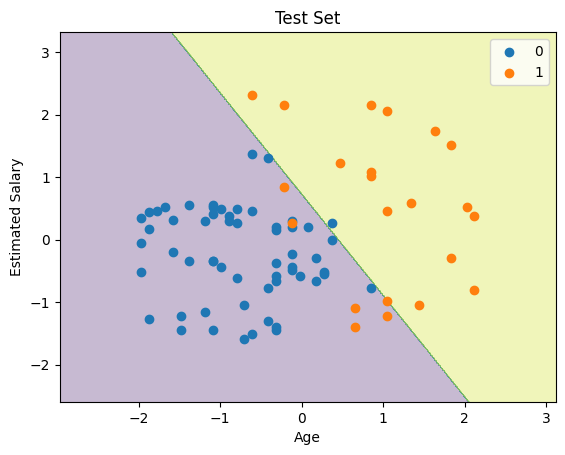

In [ ]:
plot_decision_boundary(X_train, y_train, 'Training Set')

plot_decision_boundary(X_test, y_test, 'Test Set')

EX: Soft Margin

In [ ]:
dataset['AgeSalary'] = dataset['Age'] * dataset['EstimatedSalary']

In [ ]:
X = dataset[['Age','EstimatedSalary', 'AgeSalary']].values
y = dataset['Purchased']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
model1 = SVC(kernel = 'rbf', gamma='scale', C=1.0, random_state=0)
model1.fit(X_train, y_train)

SVC(random_state=0)

In [ ]:
y_pred1 = model1.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred1)

0.95

In [ ]:
cm = confusion_matrix(y_test,y_pred1)
cm

array([[55,  3],
       [ 1, 21]])

In [ ]:
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        58
           1       0.88      0.95      0.91        22

    accuracy                           0.95        80
   macro avg       0.93      0.95      0.94        80
weighted avg       0.95      0.95      0.95        80



In [ ]:
def plot_decision_boundary(X_set, y_set, title):
    X1, X2 = np.meshgrid(
        np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
        np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
    )

    plt.figure()
    plt.contourf(
        X1, X2,
        model1.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
        alpha=0.3
    )

    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(
            X_set[y_set == j, 0],
            X_set[y_set == j, 1],
            label=j
        )

    plt.title(title)
    plt.xlabel('Age')
    plt.ylabel('Estimated Salary')
    plt.legend()

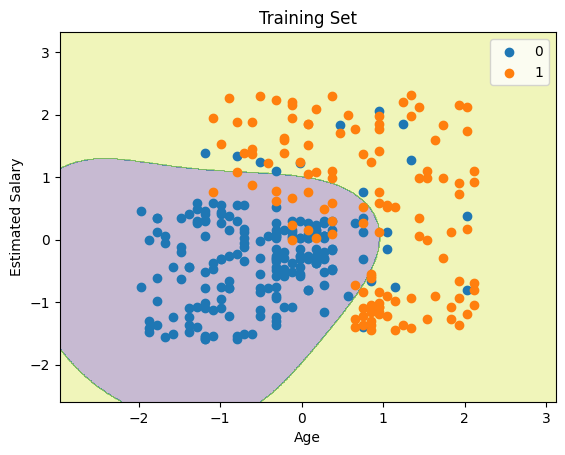

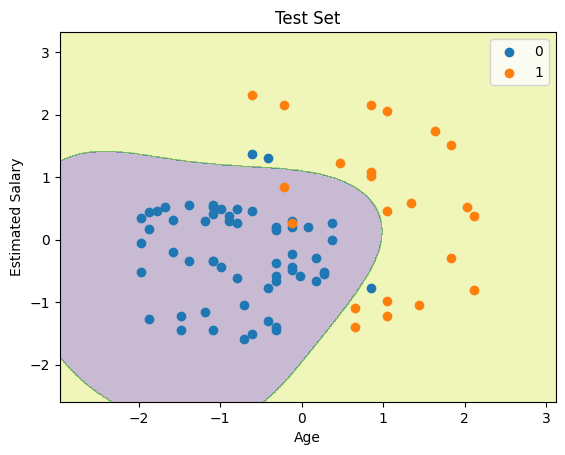

In [ ]:
def plot_decision_boundary(X_set, y_set, title):
    # Create meshgrid based on the first two features for 2D plotting
    X1, X2 = np.meshgrid(
        np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
        np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
    )

    plt.figure()

    # To predict with model1, which expects 3 features, we need to add a third feature.
    # We'll use the mean of the third feature (AgeSalary) from the X_set.
    # X_set is already scaled, so we take the mean of the scaled third column.
    mean_third_feature = X_set[:, 2].mean()

    # Create an array for prediction by combining X1, X2, and the constant third feature
    X_grid_2d = np.array([X1.ravel(), X2.ravel()]).T
    X_grid_3d = np.hstack((X_grid_2d, np.full((X_grid_2d.shape[0], 1), mean_third_feature)))

    plt.contourf(
        X1, X2,
        model1.predict(X_grid_3d).reshape(X1.shape),
        alpha=0.3
    )

    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(
            X_set[y_set == j, 0],
            X_set[y_set == j, 1],
            label=j
        )

    plt.title(title)
    plt.xlabel('Age')
    plt.ylabel('Estimated Salary')
    plt.legend()

# Now call the locally redefined function
plot_decision_boundary(X_train, y_train, 'Training Set')

plot_decision_boundary(X_test, y_test, 'Test Set')

Hyperparameter Tunning : Grid search

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid ={
    'C' : [0.1,1,10,100],
    'gamma' : [1,0.1,0.01,0.001],
    'kernel' : ['rbf']
}

In [ ]:
grid = GridSearchCV(estimator=SVC(), param_grid=param_grid, scoring='accuracy', cv=5, n_jobs=-1)

In [ ]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf']},
             scoring='accuracy')

In [ ]:
grid.best_params_

{'C': 1, 'gamma': 1, 'kernel': 'rbf'}

In [ ]:
grid.best_score_

np.float64(0.90625)

In [ ]:
grid.best_estimator_

SVC(C=1, gamma=1)

Normal execution after Gridsearch application


In [ ]:
y_pred = model1.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred)

0.95

Ex: College Dataset

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import LinearSVC, SVC

In [ ]:
dataset = pd.read_csv('/content/College.csv')
dataset.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [ ]:
dataset.shape

(777, 18)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Private      777 non-null    object 
 1   Apps         777 non-null    int64  
 2   Accept       777 non-null    int64  
 3   Enroll       777 non-null    int64  
 4   Top10perc    777 non-null    int64  
 5   Top25perc    777 non-null    int64  
 6   F.Undergrad  777 non-null    int64  
 7   P.Undergrad  777 non-null    int64  
 8   Outstate     777 non-null    int64  
 9   Room.Board   777 non-null    int64  
 10  Books        777 non-null    int64  
 11  Personal     777 non-null    int64  
 12  PhD          777 non-null    int64  
 13  Terminal     777 non-null    int64  
 14  S.F.Ratio    777 non-null    float64
 15  perc.alumni  777 non-null    int64  
 16  Expend       777 non-null    int64  
 17  Grad.Rate    777 non-null    int64  
dtypes: float64(1), int64(16), object(1)
memory usage: 

In [ ]:
dataset.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


In [ ]:
dataset.isna().sum()

,0
Private,0
Apps,0
Accept,0
Enroll,0
Top10perc,0
Top25perc,0
F.Undergrad,0
P.Undergrad,0
Outstate,0
Room.Board,0


<Axes: xlabel='Private', ylabel='count'>

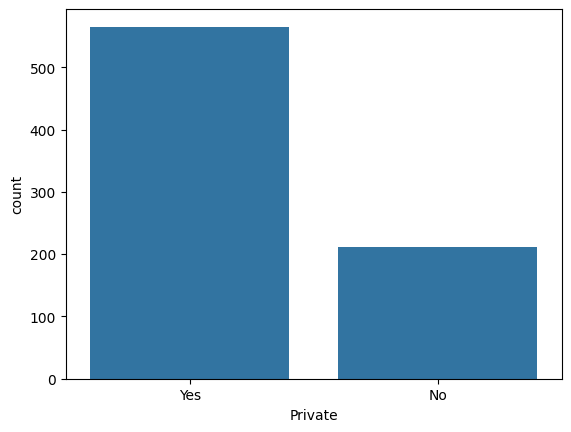

In [ ]:
sns.countplot(x = dataset['Private'])

In [ ]:
dataset['Private'] = dataset['Private'].map({'Yes': 1, 'No': 0})

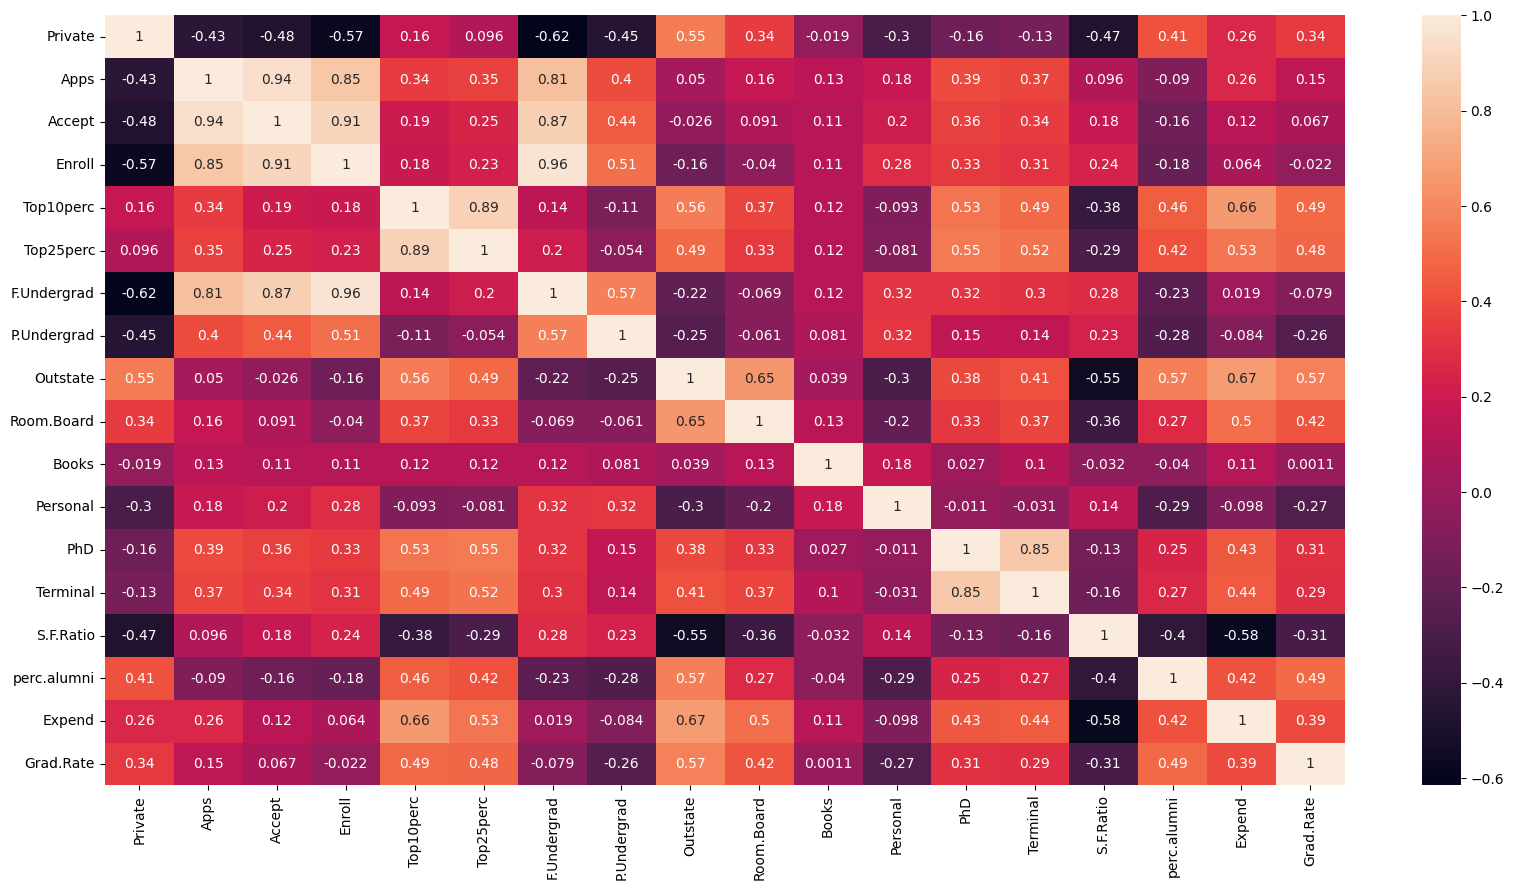

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(dataset.corr(), annot=True)
plt.show()


In [ ]:
dataset

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,1,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,1,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,1,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,1,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,0,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,1,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,1,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,1,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


In [ ]:
X = dataset.iloc[:,1:].values
y = dataset.iloc[:,0].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

**Linear Model**

In [ ]:
lr_model = LinearSVC()
lr_model.fit(X_train, y_train)

LinearSVC()

In [ ]:
y_pred_lr = lr_model.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred_lr)
#

0.9230769230769231

In [ ]:
confusion_matrix(y_test, y_pred_lr)
#

array([[ 36,   5],
       [  7, 108]])

In [ ]:
print(classification_report(y_test, y_pred_lr))
#

              precision    recall  f1-score   support

           0       0.84      0.88      0.86        41
           1       0.96      0.94      0.95       115

    accuracy                           0.92       156
   macro avg       0.90      0.91      0.90       156
weighted avg       0.92      0.92      0.92       156



**Kernel RBF Model**

In [ ]:
rbf_model = SVC(kernel = 'rbf', random_state=0 )
rbf_model.fit(X_train, y_train)

SVC(random_state=0)

In [ ]:
y_pred_rf = rbf_model.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred_rf)

0.9294871794871795

In [ ]:
confusion_matrix(y_test, y_pred_rf)

array([[ 36,   5],
       [  6, 109]])

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87        41
           1       0.96      0.95      0.95       115

    accuracy                           0.93       156
   macro avg       0.91      0.91      0.91       156
weighted avg       0.93      0.93      0.93       156



**Hypertunning using GridSearchCV**

In [ ]:
param_grid ={
    'C' : [0.1,1,10],
    'gamma' : ['scale', 0.1,0.01],
    'kernel': ['rbf']
}

In [ ]:
grid = GridSearchCV(estimator=SVC(), param_grid=param_grid,cv=10, scoring='accuracy',n_jobs=-1)

In [ ]:
grid.fit(X_train,y_train)

GridSearchCV(cv=10, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 0.1, 0.01],
                         'kernel': ['rbf']},
             scoring='accuracy')

In [ ]:
grid.best_params_

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

In [ ]:
grid.best_score_

np.float64(0.9435483870967742)

In [ ]:
grid.best_estimator_

SVC(C=10, gamma=0.01)

**Heart Risk detection**

In [ ]:
df = pd.read_csv('/content/heart (1).csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


<Axes: xlabel='target', ylabel='count'>

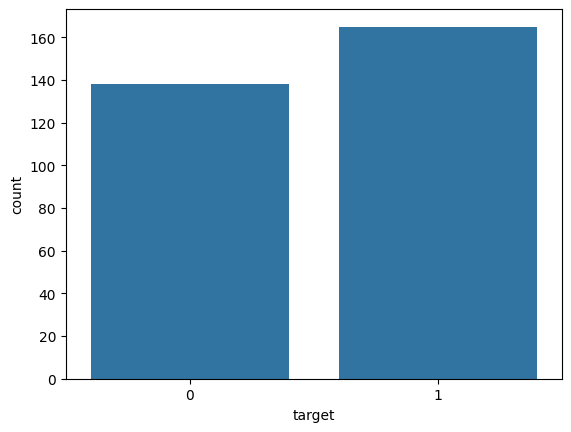

In [ ]:
sns.countplot(x=df['target'])

(array([ 1.,  0.,  6.,  5.,  7., 26., 19., 19., 12., 25., 32., 28., 44.,
        19., 19., 24.,  7.,  7.,  1.,  2.]),
 array([29. , 31.4, 33.8, 36.2, 38.6, 41. , 43.4, 45.8, 48.2, 50.6, 53. ,
        55.4, 57.8, 60.2, 62.6, 65. , 67.4, 69.8, 72.2, 74.6, 77. ]),
 <BarContainer object of 20 artists>)

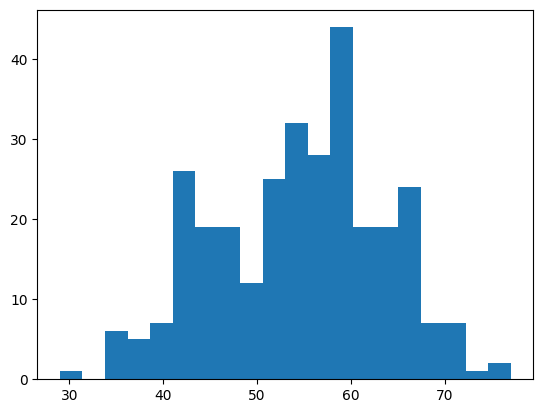

In [ ]:
plt.hist(df['age'], bins=20)

(array([[ 0.,  3.,  8., 13., 12., 29., 43., 23.,  6.,  1.],
        [ 1.,  8., 25., 25., 25., 31., 20., 20.,  8.,  2.]]),
 array([29. , 33.8, 38.6, 43.4, 48.2, 53. , 57.8, 62.6, 67.4, 72.2, 77. ]),
 <a list of 2 BarContainer objects>)

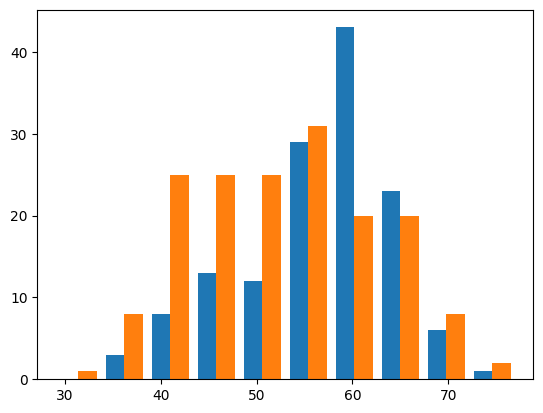

In [ ]:
plt.hist([df[df.target==0].age, df[df.target==1].age], label=["No Disease","Disease"])

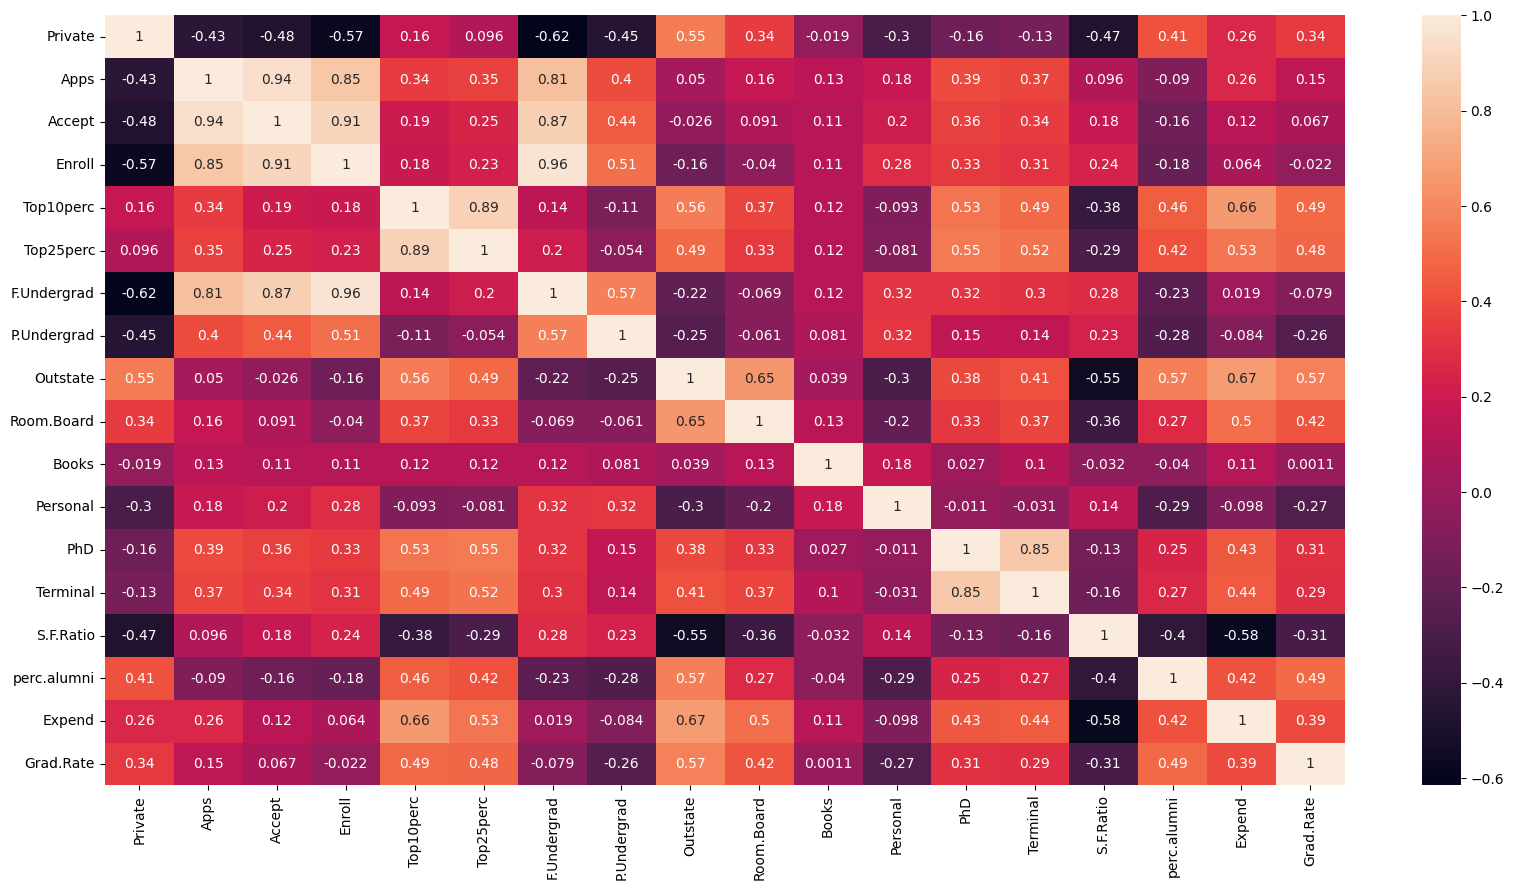

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(dataset.corr(), annot=True)
plt.show()